# Foot pressure maps by surface — left insole, flat-foot instant

One map per surface class (grass / loose / paved) on the **size-42 left insole**, with the
**12 sensor zones** filled by their mean pressure **at the flat-foot instant**.

Unlike the earlier version built from `*_dry.csv`, this recomputes from the **raw
recordings**, because the compiled tables don't contain the flat-foot instant:
`pressure_NN_mean_ratio` is `mean(seg_s) / norm_denom` in `extract_step_features`, i.e.
a mean over the **whole step window**. The flat-foot instant is computed in that same
function but only consumed by `gu_spatial_entropy_ff` / `gu_participation_ff` /
`gu_active_sensors` — the 12 values themselves are never exported.

Segmentation, the step-filtering gate and the flat-foot definition below are copied
verbatim from `ground_condition_xgboost_v21_merged_3class.ipynb`, so the steps that reach
this figure are exactly the steps that reach the models.


## 1. Configuration

In [3]:
import json, os, glob, re
from pathlib import Path

import matplotlib as mpl
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import matplotlib.patheffects
import numpy as np
import pandas as pd
from scipy import ndimage as ndi
from scipy.signal import find_peaks, savgol_filter

# ── paths ────────────────────────────────────────────────────────────────────
# Set these to wherever the three kinds of input actually live. Plain strings are
# fine: everything is coerced to pathlib.Path below, so os.path.join() results,
# raw strings and Path objects all work.
REPO_ROOT   = '..'                                   # as in the v21 notebook
RAW_DIR     = os.path.join(REPO_ROOT, 'all')         # the REC_*.csv recordings
ASSET_DIR   = os.path.join(REPO_ROOT, 'all')                               # insole PNG + cop_coords.py
COMPILED_DIR = os.path.join(REPO_ROOT, 'all')       # grass/loose/paved _dry.csv
OUT_DIR     = 'figures'
REC_GLOB    = 'REC_*.csv'

RAW_DIR, ASSET_DIR, COMPILED_DIR, OUT_DIR = (
    Path(RAW_DIR), Path(ASSET_DIR), Path(COMPILED_DIR), Path(OUT_DIR))
OUT_DIR.mkdir(parents=True, exist_ok=True)

INSOLE_PNG = ASSET_DIR / 'insole_42_complete_380p.png'
COORDS_PY  = ASSET_DIR / 'cop_coords.py'
# optional: used only to attribute each recording to a walker
COMPILED   = {s: COMPILED_DIR / f'{s}_dry.csv' for s in ('grass', 'loose', 'paved')}

FOOT      = 'left'               # left insole only -> sole_id 2
SOLE_ID   = {'left': 2, 'right': 1}[FOOT]     # per the Stappone manual
SOLE_W_MM, SOLE_L_MM = 106.3, 271.3           # size 42

WINDOW      = 'flat_foot'        # 'flat_foot' (what was asked for) or 'stance'
VALUE_MODE  = 'raw'              # 'raw' (sensor counts) | 'share' (% of the 12-sensor sum) | 'per_area'

# 'user'  = one row of maps per walker (raw counts are person-specific, so this is the
#           only honest way to show them); 'none' = pool walkers into one row per surface
FACET       = 'user'
# colour scale when faceting: 'per_user' gives each walker their own scale so the
# surface differences inside a row are visible; 'shared' puts everyone on one scale,
# which mostly shows who is heavier
SCALE       = 'per_user'

# How the 12 zone values become a picture:
#   'blend' = zone fill diffused across the whole sole and smoothed (the app look)
#   'zones' = flat fill, one colour per zone, gaps left blank (most literal)
#   'rbf'   = radial-basis interpolation from the 12 sensor POINTS (see 5b: it distorts)
RENDER        = 'blend'
BLEND_SIGMA_PX = 18.0            # smoothing width in image pixels (~3.3 px/mm)
CMAP_ABS, CMAP_DEV = 'turbo', 'RdBu_r'
AGGREGATION = 'balanced'         # 'balanced' (mean of per-user means) | 'plain'
# Only needed when walkers are POOLED: faceting by walker removes the confound, so a
# walker missing one surface just leaves that panel blank instead of skewing a mean.
COMMON_USERS_ONLY = False

# ── copied verbatim from the v21 config cell ─────────────────────────────────
HEEL_SENSORS     = ['pressure_08', 'pressure_11']
FOREFOOT_SENSORS = ['pressure_02', 'pressure_04', 'pressure_05',
                    'pressure_06', 'pressure_09']
ALL_SENSORS      = [f'pressure_{i:02d}' for i in range(1, 13)]
SMOOTH_WIN=11; SMOOTH_POLY=2; PEAK_DIST=50; PEAK_PROM=200; PEAK_HT=500
SAMPLING_HZ=62.5; HILL_WIN=10; MIN_DP=5
SURFACE_MAP = {
    'grass': 'grass',
    'dirt': 'loose', 'compact ground': 'loose', 'compacted ground': 'loose',
    'concrete': 'paved', 'asphalt': 'paved', 'exposed aggregate': 'paved', 'brick': 'paved'
}
BASE_COLS = set(
    ['sole_id','timestamp','accel_x','accel_y','accel_z',
     'gyro_x','gyro_y','gyro_z','magn_x','magn_y','magn_z','corrupt']
    + ALL_SENSORS)
EXCLUDE_TRANSITION_STEPS    = True
TRANSITION_MIN_LABELED_FRAC = 0.80
EXCLUDE_TAGS  = ['transition', 'wait']
EXCLUDE_LABEL = '__exclude__'
QUALITY_CHECK = True; QUALITY_SKIP_BAD = True
QUALITY_MAX_MISSING_PCT = 5.0; QUALITY_MIN_ROWS = 100
SURFACE_COLORS = {'paved':'#607D8B','grass':'#4CAF50','loose':'#8D6E63'}

mpl.rcParams.update({'figure.dpi': 130, 'savefig.dpi': 220, 'font.size': 9})

In [4]:
# ── where did everything resolve to? ────────────────────────────────────────
_recs = sorted(RAW_DIR.glob(REC_GLOB))
print(f'RAW_DIR      {RAW_DIR.resolve()}   ->  {len(_recs)} recording(s)')
print(f'ASSET_DIR    {ASSET_DIR.resolve()}')
print(f'COMPILED_DIR {COMPILED_DIR.resolve()}')
print(f'OUT_DIR      {OUT_DIR.resolve()}')

if not _recs:
    raise FileNotFoundError(
        f'no files matching {REC_GLOB} under {RAW_DIR.resolve()} — set RAW_DIR above')
if not INSOLE_PNG.exists():
    raise FileNotFoundError(
        f'{INSOLE_PNG.resolve()} not found — set ASSET_DIR to the folder holding '
        'insole_42_complete_380p.png (it ships inside cop_coords.zip)')
for _s, _p in COMPILED.items():
    if not _p.exists():
        print(f'  note: {_p.name} not found — walker attribution and the step-count '
              'check in 4b will be skipped')
        break
print('\nall required inputs present' if INSOLE_PNG.exists() else '')

RAW_DIR      C:\Users\Sam\WalkSensePlace\all   ->  53 recording(s)
ASSET_DIR    C:\Users\Sam\WalkSensePlace\all
COMPILED_DIR C:\Users\Sam\WalkSensePlace\all
OUT_DIR      C:\Users\Sam\WalkSensePlace\notebooks\figures

all required inputs present


## 2. Pipeline functions — verbatim from v21

`get_surface_cols`, `label_surface_segments`, `step_surface_label`, `preprocess`,
`find_step_windows` and `check_recording_quality` are unchanged copies. Don't edit them
here; edit them in v21 and re-copy, or the figure stops describing the modelled steps.


In [5]:
def get_surface_cols(df):
    return [c for c in df.columns if c not in BASE_COLS and c in SURFACE_MAP]


def label_surface_segments(df):
    """Parse 'x' markers to label each row with a surface. Each surface marker starts
    a region that runs until the NEXT marker. Columns named in EXCLUDE_TAGS (e.g.
    'transition', 'wait') start an EXCLUDED region (EXCLUDE_LABEL): those rows are kept
    for continuity but their steps are DROPPED downstream, never relabelled as a
    neighbouring surface."""
    surf_cols = get_surface_cols(df)
    excl_cols = [c for c in df.columns if c not in BASE_COLS and c in EXCLUDE_TAGS]
    if not surf_cols and not excl_cols: return None
    df = df.copy().sort_values('timestamp').reset_index(drop=True)
    events = []
    for col in surf_cols:
        mask = df[col].notna() & (df[col].astype(str).str.strip() == 'x')
        for idx in df.index[mask]: events.append((int(idx), SURFACE_MAP[col]))
    for col in excl_cols:
        mask = df[col].notna() & (df[col].astype(str).str.strip() == 'x')
        for idx in df.index[mask]: events.append((int(idx), EXCLUDE_LABEL))
    if not events: return None
    events.sort(key=lambda e: e[0])
    df['surface'] = None
    for k, (start_idx, lab) in enumerate(events):
        end_idx = events[k+1][0] if k+1 < len(events) else len(df)
        df.loc[start_idx:end_idx-1, 'surface'] = lab
    return df[df['surface'].notna()].copy()


def step_surface_label(surf_slice, default=None, stats=None):
    """Surface for ONE step window, or (None, reason) if the step must be dropped."""
    ws = pd.Series(surf_slice)
    if (ws == EXCLUDE_LABEL).any():
        if stats is not None: stats['excluded'] += 1
        return None, 'excluded'
    lab = ws.dropna()
    if EXCLUDE_TRANSITION_STEPS:
        if stats is not None: stats['seen'] += 1
        if lab.nunique() > 1:
            if stats is not None: stats['transition'] += 1
            return None, 'transition'
        if len(lab) < TRANSITION_MIN_LABELED_FRAC * len(ws):
            if stats is not None: stats['partial'] += 1
            return None, 'partial'
        if stats is not None: stats['kept'] += 1
    if not len(lab):
        return default, None
    return lab.mode()[0], None


def preprocess(df):
    df = df.copy().sort_values('timestamp').reset_index(drop=True)
    df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
    df['time_sec']  = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0
    return df


def find_step_windows(df):
    y_comb = sum(
        pd.to_numeric(df[s], errors='coerce').fillna(0).to_numpy(dtype=float)
        for s in HEEL_SENSORS if s in df.columns
    )
    n=len(y_comb); sw=min(SMOOTH_WIN, n-(0 if n%2==1 else 1))
    if sw%2==0: sw-=1
    if sw<=SMOOTH_POLY: sw=SMOOTH_POLY+3+(1 if (SMOOTH_POLY+3)%2==0 else 0)
    y_sm = savgol_filter(y_comb, window_length=sw, polyorder=min(SMOOTH_POLY, sw-1))
    peaks, _ = find_peaks(y_sm, distance=PEAK_DIST, prominence=PEAK_PROM, height=PEAK_HT)
    return peaks


def check_recording_quality(raw, path):
    """Scan a raw recording for missing / bad / outlier data. ok=False fails the gate."""
    imu  = ['accel_x','accel_y','accel_z','gyro_x','gyro_y','gyro_z']
    sens = [c for c in ALL_SENSORS if c in raw.columns]
    cols = [c for c in imu + sens if c in raw.columns]
    n    = len(raw)
    num  = raw[cols].apply(pd.to_numeric, errors='coerce') if cols else pd.DataFrame()
    pct_missing = float(num.isna().mean().mean() * 100) if cols else 100.0
    soles = set(pd.to_numeric(raw['sole_id'], errors='coerce').dropna().unique()) if 'sole_id' in raw else set()
    both_soles = {1, 2} <= soles
    ok = (n >= QUALITY_MIN_ROWS) and both_soles and (pct_missing <= QUALITY_MAX_MISSING_PCT)
    return ok, {'rows': n, 'both_soles': bool(both_soles),
                'pct_missing': round(pct_missing, 2), 'verdict': 'OK' if ok else 'FAIL'}

### 2b. The flat-foot instant

Lifted from `extract_step_features`, lines that compute `m_loc` and `_ffm`:

```python
c_loc  = int(np.argmin(wh))                      # heel minimum -> start of the window
diff   = np.abs(whn[c_loc:] - wfn[c_loc:])       # heel vs forefoot, per-sensor normalised
m_loc  = c_loc + int(np.argmin(diff))            # where they balance = flat foot
_a0, _a1 = max(0, m_loc-3), min(n_win, m_loc+4)  # +/- 3 samples (~+/-48 ms at 62.5 Hz)
_ffm   = _Pw[_a0:_a1].mean(0)                    # 12-vector: mean per zone
```

So "the average from each zone at the flat-foot instant" is a 7-sample mean centred on
the heel/forefoot balance point. `WINDOW = 'stance'` swaps `_ffm` for `_Pw.mean(0)`,
which reproduces what the compiled CSVs contain (before their `norm_denom` division).


In [6]:
_FILTER_STATS = {'seen': 0, 'transition': 0, 'partial': 0, 'kept': 0, 'excluded': 0}


def zone_means_per_step(df, window=WINDOW, stats=None):
    """Per-step 12-zone means for ONE sole of ONE recording.
    Returns (array [n_steps, 12], list of surface labels)."""
    heel_sig = df[HEEL_SENSORS].apply(pd.to_numeric, errors='coerce').sum(axis=1).fillna(0).values
    fore_sig = df[FOREFOOT_SENSORS].apply(pd.to_numeric, errors='coerce').sum(axis=1).fillna(0).values
    heel_norm = heel_sig / len(HEEL_SENSORS)
    fore_norm = fore_sig / len(FOREFOOT_SENSORS)
    P = df[ALL_SENSORS].apply(pd.to_numeric, errors='coerce').fillna(0).to_numpy(float)

    peaks = find_step_windows(df)
    if len(peaks) < 2:
        return np.empty((0, 12)), []
    has_labels = ('surface' in df.columns) and bool(df['surface'].notna().any())

    out, surfs = [], []
    for i in range(len(peaks) - 1):
        p1, p2 = peaks[i], peaks[i+1]
        wh = heel_sig[p1:p2]
        if len(wh) < MIN_DP:
            continue
        surf = None
        if has_labels:
            surf, drop = step_surface_label(df['surface'].iloc[p1:p2], stats=stats)
            if drop:
                continue
        whn = heel_norm[p1:p2]; wfn = fore_norm[p1:p2]
        Pw = P[p1:p2]; n_win = len(wh)
        if window == 'flat_foot':
            c_loc = int(np.argmin(wh))
            diff  = np.abs(whn[c_loc:] - wfn[c_loc:])
            m_loc = c_loc + int(np.argmin(diff))
            a0, a1 = max(0, m_loc-3), min(n_win, m_loc+4)
            seg = Pw[a0:a1]
            v = seg.mean(0) if len(seg) else Pw.mean(0)
        elif window == 'stance':
            v = Pw.mean(0)
        else:
            raise ValueError(window)
        out.append(v); surfs.append(surf)
    return (np.array(out) if out else np.empty((0, 12))), surfs

## 3. Run over the recordings

In [7]:
recs = sorted(str(p) for p in RAW_DIR.glob(REC_GLOB))
print(f'{len(recs)} recordings found')

rows, skipped = [], []
for path in recs:
    raw = pd.read_csv(path, low_memory=False)
    if QUALITY_CHECK and QUALITY_SKIP_BAD:
        ok, rep = check_recording_quality(raw, path)
        if not ok:
            skipped.append((os.path.basename(path), rep)); continue
    sub = raw[pd.to_numeric(raw['sole_id'], errors='coerce') == SOLE_ID]
    if sub.empty:
        continue
    lab = label_surface_segments(sub)
    if lab is None:
        continue
    lab = preprocess(lab)
    vals, surfs = zone_means_per_step(lab, stats=_FILTER_STATS)
    for v, s in zip(vals, surfs):
        if s in ('grass', 'loose', 'paved'):
            rows.append(dict(recording=os.path.basename(path), surface=s,
                             **{f'z{k:02d}': v[k-1] for k in range(1, 13)}))

steps = pd.DataFrame(rows)
ZCOLS = [f'z{k:02d}' for k in range(1, 13)]
print(f'skipped by the quality gate: {len(skipped)}')
print(f'kept {len(steps)} {FOOT}-foot steps from '
      f'{steps["recording"].nunique()} recordings')
print('\nstep gate counters:', _FILTER_STATS)
print('\nsteps per surface:'); print(steps['surface'].value_counts().to_string())

53 recordings found
skipped by the quality gate: 0
kept 7841 left-foot steps from 53 recordings

step gate counters: {'seen': 7841, 'transition': 0, 'partial': 0, 'kept': 7841, 'excluded': 884}

steps per surface:
surface
paved    4951
grass    1887
loose    1003


## 4. Attribute each recording to a walker

The raw folder carries no user subfolders, so the walker is recovered from
`source_recording` in the compiled tables. Every recording maps to exactly one user.


In [8]:
user_of = {}
for surf, p in COMPILED.items():
    if Path(p).exists():
        c = pd.read_csv(p, usecols=['source_user', 'source_recording']).drop_duplicates()
        for u, r in c.itertuples(index=False):
            user_of.setdefault(os.path.basename(str(r)), set()).add(u)

ambiguous = {k: v for k, v in user_of.items() if len(v) > 1}
assert not ambiguous, f'recordings with more than one owner: {ambiguous}'
user_of = {k: next(iter(v)) for k, v in user_of.items()}

steps['user'] = steps['recording'].map(user_of)
unattributed = steps['user'].isna().sum()
print(f'{unattributed} steps without a walker label')
if unattributed:
    print('  -> COMMON_USERS_ONLY and balanced aggregation will ignore those steps')
print(pd.crosstab(steps['user'], steps['surface']).to_string())

steps_all = steps.copy()        # pre-restriction, used by the check in 4b
HAVE_USERS = bool(steps['user'].notna().any())
common = set(steps['user'].dropna().unique())

if not HAVE_USERS:
    # no compiled CSVs -> no walker labels; per-user work is impossible
    print('\nNO walker labels available. Falling back to AGGREGATION="plain" and '
          'disabling COMMON_USERS_ONLY.')
    print('This matters: the surface effect here is ~20x smaller than the '
          'between-person effect, so an unbalanced mean mostly reflects who walked. '
          'Supply the *_dry.csv files (or user subfolders) before trusting the figure.')
    AGGREGATION = 'plain'
    COMMON_USERS_ONLY = False
elif COMMON_USERS_ONLY:
    have = steps.dropna(subset=['user']).groupby('user')['surface'].nunique()
    common = set(have[have == 3].index)
    dropped = set(have.index) - common
    steps = steps[steps['user'].isin(common)].copy()
    print(f'\nrestricted to walkers on all three surfaces: {sorted(common)}'
          + (f'  (dropped {sorted(dropped)})' if dropped else ''))
    print(pd.crosstab(steps['user'], steps['surface']).to_string())

0 steps without a walker label
surface    grass  loose  paved
user                          
Catherine     94     29    423
Kristian     881    447   1626
Sam          823    527   2437
Samantha      89      0    465


### 4b. Does the re-implementation match the model pipeline?

The compiled tables record one row per kept step, so the left-foot row count per
recording should match what this notebook keeps. A mismatch means the segmentation or
the gate has drifted and the figure no longer describes the modelled steps.


In [9]:
mine = steps_all.groupby('recording').size()   # BEFORE the common-user restriction
theirs = {}
for surf, p in COMPILED.items():
    if Path(p).exists():
        c = pd.read_csv(p, usecols=['foot', 'source_recording'])
        c = c[c['foot'] == FOOT]
        for r, n in c['source_recording'].map(os.path.basename).value_counts().items():
            theirs[r] = theirs.get(r, 0) + int(n)
theirs = pd.Series(theirs, dtype=int)
if theirs.empty:
    print('compiled CSVs not available — skipping the step-count reconciliation')
    cmp_df = pd.DataFrame(columns=['this_notebook', 'compiled_csv', 'diff'])
if not theirs.empty:
    cmp_df = pd.DataFrame({'this_notebook': mine}).join(
        pd.DataFrame({'compiled_csv': theirs}), how='outer').fillna(0).astype(int)
    cmp_df['diff'] = cmp_df['this_notebook'] - cmp_df['compiled_csv']
    cmp_df = cmp_df[cmp_df[['this_notebook', 'compiled_csv']].max(axis=1) > 0]
print(f'recordings compared: {len(cmp_df)}')
print(f'totals -> this notebook {cmp_df["this_notebook"].sum()}, '
      f'compiled {cmp_df["compiled_csv"].sum()}, '
      f'net {cmp_df["diff"].sum():+d}')
off = cmp_df[cmp_df['diff'] != 0]
print(f'recordings differing: {len(off)}')
if len(off):
    print(off.to_string())
    print('\nSmall differences are expected where a recording contributes steps on a '
          'surface outside the 3-class map, or was dropped by a gate on only one side.')

recordings compared: 53
totals -> this notebook 7841, compiled 7841, net +0
recordings differing: 0


## 5. Sensor metadata and zone polygons

In [10]:
COORDS_LEFT = [[0.7438, 0.8713], [0.7979, 0.7165], [0.6264, 0.5308], [0.4839, 0.7074],
               [0.6441, 0.7103], [0.3293, 0.6891], [0.2920, 0.4243], [0.3119, 0.1321],
               [0.1844, 0.6659], [0.5604, 0.2574], [0.5396, 0.1170], [0.4226, 0.8585]]
COORDS_RIGHT = [[0.2562, 0.8713], [0.2021, 0.7165], [0.3736, 0.5308], [0.5161, 0.7074],
                [0.3559, 0.7103], [0.6707, 0.6891], [0.7080, 0.4243], [0.6881, 0.1321],
                [0.8156, 0.6659], [0.4396, 0.2574], [0.4604, 0.1170], [0.5774, 0.8585]]
AREAS = [0.0804, 0.0637, 0.0931, 0.0750, 0.0762, 0.0724,
         0.1490, 0.0574, 0.0526, 0.0897, 0.0657, 0.1249]

if COORDS_PY.exists():
    src = COORDS_PY.read_text()
    def _grab(name):
        blk = src.split(name)[1].split(']]')[0] + ']]'
        return [[float(v) for v in p.split(',')]
                for p in re.findall(r'\[([-\d.]+,\s*[-\d.]+)\]', blk)]
    assert _grab('coords_left_normalized') == COORDS_LEFT, 'left coords drifted'
    assert _grab('coords_right_normalized') == COORDS_RIGHT, 'right coords drifted'
    print('sensor coordinates verified against cop_coords.py')
COORDS = COORDS_LEFT if FOOT == 'left' else COORDS_RIGHT

# zone polygons from the insole line art: dilate the stippled contours to close them,
# take the enclosed regions, claim one per sensor coordinate
rgba = (mpimg.imread(INSOLE_PNG) * 255).astype(np.uint8)
alpha = rgba[..., 3]
IMG_H, IMG_W = alpha.shape
# dilate by one pixel to close the stippled contours, then label the enclosed regions
closed = ndi.binary_dilation(alpha > 20, structure=np.ones((3, 3), bool))
comp, n_comp = ndi.label(~closed, structure=np.ones((3, 3), bool))

zone_of_sensor = {k: int(comp[int(round((1-yn)*IMG_H)), int(round(xn*IMG_W))])
                  for k, (xn, yn) in enumerate(COORDS, start=1)}
assert len(set(zone_of_sensor.values())) == 12, (
    f'sensors collapsed onto {len(set(zone_of_sensor.values()))} regions — '
    'wrong foot, wrong graphic, or the dilation merged two zones')

ZONES = np.zeros_like(comp, dtype=np.uint8)
for k, c in zone_of_sensor.items():
    ZONES[comp == c] = k
print('12 zone polygons extracted; the artwork is a LEFT insole '
      '(right-foot coordinates hit only 8 distinct regions)')

# the sole silhouette: the line art is one closed outer contour, so filling the holes
# in it yields the whole insole interior
SOLE = ndi.binary_fill_holes(closed)
cover = 100 * ((ZONES > 0) & SOLE).sum() / SOLE.sum()
gap_px = ndi.distance_transform_edt(ZONES == 0)[SOLE].max()
print(f'sensor zones cover {cover:.0f}% of the sole area; the farthest sole pixel is '
      f'{gap_px:.0f} px (~{gap_px/(IMG_H/SOLE_L_MM):.0f} mm) from any zone')

sensor coordinates verified against cop_coords.py
12 zone polygons extracted; the artwork is a LEFT insole (right-foot coordinates hit only 8 distinct regions)
sensor zones cover 40% of the sole area; the farthest sole pixel is 71 px (~20 mm) from any zone


### 5b. Turning 12 numbers into a surface

Three renderings, and the choice is not cosmetic. The zones cover only ~40% of the sole
area and the farthest sole pixel is ~21 mm from any sensor zone, so **most of the
coloured area in a smooth map is interpolation, not measurement.**

* `blend` — each zone is seeded with its own mean, then the values are diffused into the
  unseeded gaps by normalised (mask-aware) convolution and smoothed once more. Seeded
  pixels are restored after every pass, so the zone means stay anchored: the measured
  extremes survive and each zone's mean shifts by only ~0.2 points.
* `zones` — flat fill. Nothing is invented, but the gaps stay blank.
* `rbf` — radial-basis interpolation from the 12 sensor *points*, the method used in the
  physicalization script and the earlier pressure-map figures. With multiquadric /
  smooth=3 it **compresses the range from 5.4-13.0 down to 7.9-12.1 and shifts per-zone
  means by 1.7 points on average, 3.8 at worst** — several times the largest
  between-surface effect in this dataset. Included for comparison; not recommended here.

The fidelity numbers for whichever mode you pick are printed in section 7.


In [11]:
def field_from_zone_values(vals, render=None, sigma_px=None):
    """12 zone values -> a full-sole image, NaN outside the silhouette."""
    render = render or RENDER
    sigma_px = BLEND_SIGMA_PX if sigma_px is None else sigma_px

    if render == 'zones':
        out = np.full(ZONES.shape, np.nan)
        for k in range(1, 13):
            out[ZONES == k] = vals[k - 1]
        return out

    if render == 'rbf':
        from scipy.interpolate import Rbf
        px = np.array([c[0] for c in COORDS]) * IMG_W
        py = (1 - np.array([c[1] for c in COORDS])) * IMG_H
        gy, gx = np.mgrid[0:IMG_H, 0:IMG_W]
        out = Rbf(px, py, vals, function='multiquadric', smooth=3)(gx, gy)
        out[~SOLE] = np.nan
        return out

    if render != 'blend':
        raise ValueError(render)

    # seed each zone with its mean
    v = np.zeros(ZONES.shape, float); w = np.zeros(ZONES.shape, float)
    for k in range(1, 13):
        m = ZONES == k
        v[m] = vals[k - 1]; w[m] = 1.0
    seed_v, seed_w = v.copy(), w.copy()

    # diffuse into the gaps: blur value*weight and weight together, then divide, so the
    # empty background never drags the result toward zero. Re-anchor the seeds each pass.
    s = sigma_px / 3.0
    for _ in range(6):
        num = ndi.gaussian_filter(v * w, s, mode='nearest')
        den = ndi.gaussian_filter(w, s, mode='nearest')
        v = np.where(seed_w > 0, seed_v, num / np.maximum(den, 1e-9))
        w = ((den > 1e-6) | (seed_w > 0)).astype(float)
        s *= 1.6
        if w[SOLE].min() > 0:
            break

    num = ndi.gaussian_filter(v * w, sigma_px, mode='nearest')
    den = ndi.gaussian_filter(w, sigma_px, mode='nearest')
    out = num / np.maximum(den, 1e-9)
    out[~SOLE] = np.nan
    return out


def zone_fidelity(vals, render=None):
    """How far the rendering moves each zone's mean away from the measured value."""
    f = field_from_zone_values(vals, render=render)
    got = np.array([np.nanmean(f[ZONES == k]) for k in range(1, 13)])
    err = np.abs(got - np.asarray(vals))
    inside = f[SOLE]
    return dict(render=render or RENDER,
                mean_shift=float(err.mean()), worst_shift=float(err.max()),
                rendered_range=(float(np.nanmin(inside)), float(np.nanmax(inside))),
                true_range=(float(np.min(vals)), float(np.max(vals))))

## 6. Aggregate

In [12]:
def zone_values(df):
    if AGGREGATION == 'balanced' and HAVE_USERS:
        v = df.groupby('user')[ZCOLS].mean().mean().to_numpy(float)
    else:
        v = df[ZCOLS].mean().to_numpy(float)
    if VALUE_MODE == 'share':
        v = 100.0 * v / v.sum()
    elif VALUE_MODE == 'per_area':
        v = (100.0 * v / v.sum()) / np.array(AREAS)
    elif VALUE_MODE != 'raw':
        raise ValueError(VALUE_MODE)
    return v

SURFS = ['grass', 'loose', 'paved']
ZIDX = [f'zone_{k:02d}' for k in range(1, 13)]
VALUES = pd.DataFrame({s: zone_values(steps[steps['surface'] == s]) for s in SURFS},
                      index=ZIDX)

# per-walker tables, used when FACET == 'user'
USERS = sorted(steps['user'].dropna().unique()) if HAVE_USERS else []
PANELS = {}          # (user, surface) -> 12 values, or None where that walker has no steps
for u in USERS:
    for s in SURFS:
        d = steps[(steps['user'] == u) & (steps['surface'] == s)]
        PANELS[(u, s)] = None if d.empty else zone_values(d)
if FACET == 'user' and HAVE_USERS:
    print('\nsteps per walker per surface:')
    print(pd.crosstab(steps['user'], steps['surface']).to_string())
    empty = [k for k, v in PANELS.items() if v is None]
    if empty:
        print(f'no steps for: {empty} — those panels are left blank')
    tot = pd.DataFrame({s: {u: (PANELS[(u, s)].sum() if PANELS[(u, s)] is not None
                                else np.nan) for u in USERS} for s in SURFS})
    print('\nflat-foot 12-sensor TOTAL per walker per surface '
          f'({"counts" if VALUE_MODE == "raw" else VALUE_MODE}):')
    print(tot.round(0).to_string())
    if VALUE_MODE == 'raw':
        print(f'\nbetween-walker spread on the total: '
              f'{tot.mean(axis=1).max()/tot.mean(axis=1).min():.2f}x — raw counts carry '
              'body weight and shoe fit, so do not read across rows.')
VALUES['mean'] = VALUES[SURFS].mean(axis=1)
VALUES['max-min'] = VALUES[SURFS].max(axis=1) - VALUES[SURFS].min(axis=1)
print(f'WINDOW={WINDOW}  VALUE_MODE={VALUE_MODE}  AGGREGATION={AGGREGATION}')
print(VALUES.round(2).to_string())
print(f'\nlargest between-surface spread {VALUES["max-min"].max():.2f} '
      f'vs typical zone value {VALUES["mean"].mean():.2f} '
      f'({100*VALUES["max-min"].max()/VALUES["mean"].mean():.0f}%)')


steps per walker per surface:
surface    grass  loose  paved
user                          
Catherine     94     29    423
Kristian     881    447   1626
Sam          823    527   2437
Samantha      89      0    465
no steps for: [('Samantha', 'loose')] — those panels are left blank

flat-foot 12-sensor TOTAL per walker per surface (counts):
            grass   loose   paved
Catherine  2422.0  2373.0  2363.0
Kristian   1066.0  1176.0  1180.0
Sam        2650.0  2732.0  2669.0
Samantha   1986.0     NaN  2011.0

between-walker spread on the total: 2.35x — raw counts carry body weight and shoe fit, so do not read across rows.
WINDOW=flat_foot  VALUE_MODE=raw  AGGREGATION=balanced
          grass   loose   paved    mean  max-min
zone_01  177.56  188.33  173.28  179.72    15.06
zone_02  133.46  146.40  134.45  138.10    12.94
zone_03  120.48  125.91  120.71  122.37     5.43
zone_04  197.25  208.13  199.88  201.75    10.88
zone_05  117.95  125.78  121.97  121.90     7.83
zone_06  204.62  197

### 6b. Person effect vs surface effect

The between-surface spread is small; the between-person spread is not. Any zone whose
person spread dwarfs its surface spread is telling you who walked, not what they walked
on.


In [13]:
if not HAVE_USERS:
    print('no walker labels — cannot separate the person effect from the surface '
          'effect, so this diagnostic is skipped. The figure is NOT safe to read as '
          'a surface comparison until walker labels are available.')
else:
    per_user = steps.groupby('user')[ZCOLS].mean()
    if VALUE_MODE in ('share', 'per_area'):
        per_user = per_user.div(per_user.sum(axis=1), axis=0) * 100
    person_spread = (per_user.max() - per_user.min()).to_numpy()
    surf_spread = VALUES['max-min'].to_numpy()

    diag = pd.DataFrame({'surface_spread': surf_spread.round(2),
                         'person_spread': person_spread.round(2)}, index=VALUES.index)
    diag['person/surface'] = (diag['person_spread'] / diag['surface_spread']).round(1)
    print(diag.to_string())
    print(f'\nmedian person/surface ratio: {diag["person/surface"].median():.1f}x')

         surface_spread  person_spread  person/surface
zone_01           15.06         229.69            15.3
zone_02           12.94         155.04            12.0
zone_03            5.43         151.89            28.0
zone_04           10.88         153.52            14.1
zone_05            7.83          91.57            11.7
zone_06            7.54         132.17            17.5
zone_07           12.53         200.11            16.0
zone_08            3.75         122.09            32.6
zone_09            3.31          70.77            21.4
zone_10           11.52         140.47            12.2
zone_11            8.37         182.09            21.8
zone_12           17.10         124.63             7.3

median person/surface ratio: 15.7x


## 7. Draw the maps

render=blend  zone means shift by 4.33 pts on average (worst 10.19); rendered range 120.48..262.10 vs measured 117.95..262.10
60% of the coloured area is interpolated between sensors — say so in the caption.


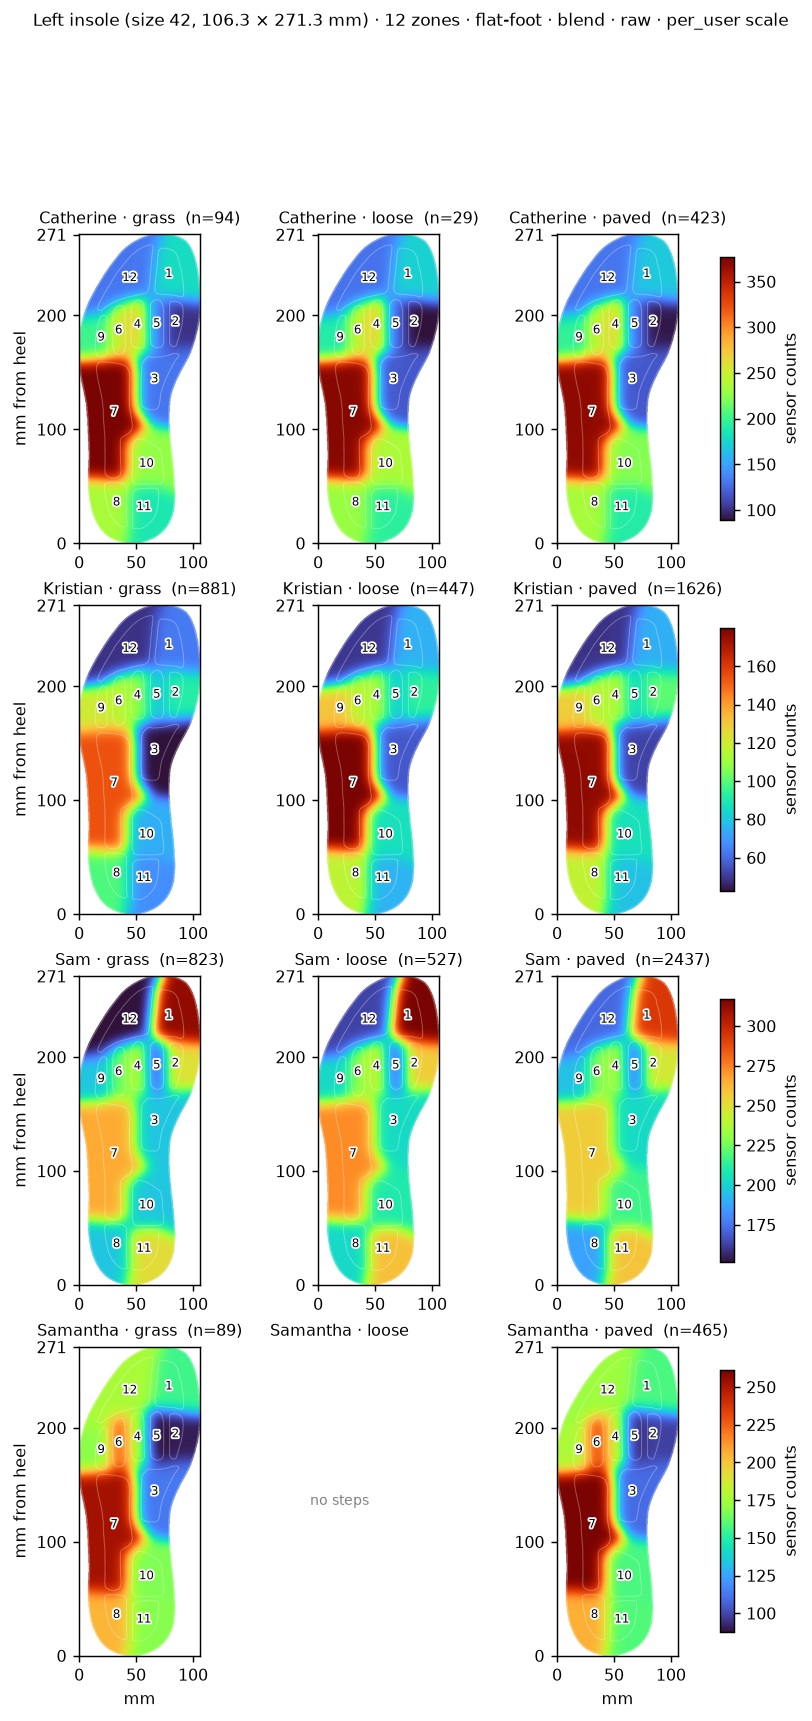

In [14]:
def draw(ax, vals, cmap, vmin, vmax, title):
    canvas = field_from_zone_values(vals)
    im = ax.imshow(canvas, origin='upper', cmap=cmap, vmin=vmin, vmax=vmax,
                   extent=[0, SOLE_W_MM, 0, SOLE_L_MM],
                   interpolation='bilinear' if RENDER != 'zones' else 'nearest')
    # zone/outline line art on top: white over a smooth field, dark over flat fill
    tint = 1.0 if RENDER != 'zones' else 0.0
    ax.imshow(np.dstack([np.full(ZONES.shape, tint)]*3 + [alpha/255.0*0.9]),
              origin='upper', extent=[0, SOLE_W_MM, 0, SOLE_L_MM])
    for k, (xn, yn) in enumerate(COORDS, start=1):
        ax.text(xn*SOLE_W_MM, yn*SOLE_L_MM, str(k), ha='center', va='center',
                fontsize=6.5, color='black',
                path_effects=[mpl.patheffects.withStroke(linewidth=2.0, foreground='white')])
    ax.set_title(title, fontsize=9)
    ax.set_xlim(0, SOLE_W_MM); ax.set_ylim(0, SOLE_L_MM)
    ax.set_xticks([0, 50, 100]); ax.set_yticks([0, 100, 200, 271])
    ax.set_aspect('equal')
    return im

abs_v = VALUES[SURFS].to_numpy()
dev_v = abs_v - VALUES['mean'].to_numpy()[:, None]

fid = zone_fidelity(abs_v[:, 0])
print(f"render={fid['render']}  zone means shift by {fid['mean_shift']:.2f} pts on "
      f"average (worst {fid['worst_shift']:.2f}); rendered range "
      f"{fid['rendered_range'][0]:.2f}..{fid['rendered_range'][1]:.2f} vs measured "
      f"{fid['true_range'][0]:.2f}..{fid['true_range'][1]:.2f}")
if RENDER != 'zones':
    print(f'{100-cover:.0f}% of the coloured area is interpolated between sensors — '
          'say so in the caption.')
unit = {'share': '% of flat-foot total', 'raw': 'sensor counts',
        'per_area': '% per unit pad area'}[VALUE_MODE]

if FACET == 'user' and HAVE_USERS:
    nrow = len(USERS)
    fig, axes = plt.subplots(nrow, 3, figsize=(8.4, 3.55 * nrow), squeeze=False)
    for i, u in enumerate(USERS):
        vals_u = [PANELS[(u, s)] for s in SURFS]
        present = [v for v in vals_u if v is not None]
        if SCALE == 'per_user' and present:
            lo, hi = min(v.min() for v in present), max(v.max() for v in present)
        else:
            allv = [v for v in PANELS.values() if v is not None]
            lo, hi = min(v.min() for v in allv), max(v.max() for v in allv)
        for j, s in enumerate(SURFS):
            ax = axes[i, j]
            n_s = int(((steps['user'] == u) & (steps['surface'] == s)).sum())
            if vals_u[j] is None:
                ax.text(0.5, 0.5, 'no steps', ha='center', va='center',
                        transform=ax.transAxes, fontsize=8, color='0.5')
                ax.set_xticks([]); ax.set_yticks([])
                for sp in ax.spines.values(): sp.set_visible(False)
                ax.set_title(f'{u} · {s}', fontsize=9)
                continue
            im = draw(ax, vals_u[j], CMAP_ABS, lo, hi, f'{u} · {s}  (n={n_s})')
            if j == 0:
                ax.set_ylabel('mm from heel')
            if i == nrow - 1:
                ax.set_xlabel('mm')
        if SCALE == 'per_user':
            fig.colorbar(im, ax=axes[i, :], shrink=0.85, label=unit)
    if SCALE == 'shared':
        fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.4, label=unit)
    fig.suptitle(f'{FOOT.capitalize()} insole (size 42, {SOLE_W_MM:.1f} × '
                 f'{SOLE_L_MM:.1f} mm) · 12 zones · {WINDOW.replace("_", "-")} · '
                 f'{RENDER} · {VALUE_MODE} · {SCALE} scale', fontsize=9.5, y=1.0)
    stem = f'pressure_maps_{WINDOW}_{RENDER}_{VALUE_MODE}_byuser'
else:
    fig, axes = plt.subplots(2, 3, figsize=(8.4, 10.0))
    for j, s in enumerate(SURFS):
        im = draw(axes[0, j], abs_v[:, j], CMAP_ABS, abs_v.min(), abs_v.max(),
                  f'{s} — absolute')
    axes[0, 0].set_ylabel('mm from heel')
    fig.colorbar(im, ax=axes[0, :], shrink=0.6, label=unit)

    lim = float(np.abs(dev_v).max())
    for j, s in enumerate(SURFS):
        im2 = draw(axes[1, j], dev_v[:, j], CMAP_DEV, -lim, lim, f'{s} — Δ from mean')
        axes[1, j].set_xlabel('mm')
    axes[1, 0].set_ylabel('mm from heel')
    fig.colorbar(im2, ax=axes[1, :], shrink=0.6, label=f'Δ {unit}')
    fig.suptitle(f'{FOOT.capitalize()} insole (size 42, {SOLE_W_MM:.1f} × '
                 f'{SOLE_L_MM:.1f} mm) · 12 zones · {WINDOW.replace("_", "-")} · '
                 f'{RENDER} · {AGGREGATION} mean · n={len(steps)} steps',
                 fontsize=9.5, y=0.999)
    stem = f'pressure_maps_{WINDOW}_{RENDER}'

fig.savefig(OUT_DIR / f'{stem}.png', bbox_inches='tight')
fig.savefig(OUT_DIR / f'{stem}.svg', bbox_inches='tight')
plt.show()

## 8. Flat-foot vs whole-stance

How much the choice of window actually changes the map. The stance column is what the
compiled `pressure_NN_mean_ratio` columns describe, so this is also the difference
between this figure and the earlier CSV-based one.


In [15]:
alt_rows = []
for path in sorted(str(p) for p in RAW_DIR.glob(REC_GLOB)):
    raw = pd.read_csv(path, low_memory=False)
    if QUALITY_CHECK and QUALITY_SKIP_BAD and not check_recording_quality(raw, path)[0]:
        continue
    sub = raw[pd.to_numeric(raw['sole_id'], errors='coerce') == SOLE_ID]
    if sub.empty: continue
    lab = label_surface_segments(sub)
    if lab is None: continue
    vals, surfs = zone_means_per_step(preprocess(lab), window='stance')
    for v, s in zip(vals, surfs):
        if s in SURFS:
            alt_rows.append(dict(recording=os.path.basename(path), surface=s,
                                 **{f'z{k:02d}': v[k-1] for k in range(1, 13)}))
alt = pd.DataFrame(alt_rows)
alt['user'] = alt['recording'].map(user_of)
if COMMON_USERS_ONLY and common:
    alt = alt[alt['user'].isin(common)]

def shares(df):
    if AGGREGATION == 'balanced' and HAVE_USERS:
        v = df.groupby('user')[ZCOLS].mean().mean().to_numpy(float)
    else:
        v = df[ZCOLS].mean().to_numpy(float)
    return 100 * v / v.sum()

cmp_win = pd.DataFrame({'flat_foot': shares(steps), 'stance': shares(alt)},
                       index=VALUES.index)
cmp_win['diff'] = (cmp_win['flat_foot'] - cmp_win['stance']).round(2)
print(cmp_win.round(2).to_string())
print(f'\nlargest window effect: {cmp_win["diff"].abs().max():.2f} points, '
      f'against a largest surface effect of {VALUES["max-min"].max():.2f}')

         flat_foot  stance  diff
zone_01       8.53    9.25 -0.73
zone_02       6.54    7.25 -0.71
zone_03       5.87    5.95 -0.08
zone_04       9.73    9.12  0.62
zone_05       5.88    6.64 -0.76
zone_06      10.02    9.51  0.50
zone_07      12.94   11.89  1.05
zone_08       9.06    8.09  0.97
zone_09       8.50    7.61  0.89
zone_10       8.26    8.98 -0.72
zone_11       8.34    7.98  0.36
zone_12       6.33    7.72 -1.39

largest window effect: 1.39 points, against a largest surface effect of 17.10


## 9. Export

In [16]:
export = VALUES.copy()
export.insert(0, 'documented_area_norm', AREAS)
export.insert(0, 'sensor', range(1, 13))
export.to_csv(OUT_DIR / f'pressure_maps_{WINDOW}.csv', index=False)
if FACET == 'user' and HAVE_USERS:
    long = pd.DataFrame([dict(user=u, surface=s, zone=k+1, value=PANELS[(u, s)][k])
                         for (u, s), v in PANELS.items() if v is not None
                         for k in range(12)])
    long.to_csv(OUT_DIR / f'pressure_maps_{WINDOW}_{VALUE_MODE}_byuser.csv', index=False)
    print(f'per-walker values -> pressure_maps_{WINDOW}_{VALUE_MODE}_byuser.csv')
steps.to_csv(OUT_DIR / f'flatfoot_zone_means_per_step_{FOOT}.csv', index=False)

meta = dict(foot=FOOT, sole_id=SOLE_ID, sole_size=42,
            sole_w_mm=SOLE_W_MM, sole_l_mm=SOLE_L_MM,
            window=WINDOW, value_mode=VALUE_MODE, aggregation=AGGREGATION,
            render=RENDER, blend_sigma_px=BLEND_SIGMA_PX,
            facet=FACET, scale=SCALE,
            zone_area_coverage_pct=round(float(cover), 1),
            common_users_only=COMMON_USERS_ONLY,
            n_steps=int(len(steps)),
            steps_per_surface={s: int((steps['surface'] == s).sum()) for s in SURFS},
            users=sorted(steps['user'].dropna().unique().tolist()),
            walker_labels_available=HAVE_USERS,
            recordings=int(steps['recording'].nunique()),
            filter_stats=_FILTER_STATS,
            source='raw REC_*.csv, segmentation and gate copied from '
                   'ground_condition_xgboost_v21_merged_3class.ipynb')
(OUT_DIR / f'pressure_maps_{WINDOW}.json').write_text(json.dumps(meta, indent=2))
print(json.dumps(meta, indent=2))

per-walker values -> pressure_maps_flat_foot_raw_byuser.csv
{
  "foot": "left",
  "sole_id": 2,
  "sole_size": 42,
  "sole_w_mm": 106.3,
  "sole_l_mm": 271.3,
  "window": "flat_foot",
  "value_mode": "raw",
  "aggregation": "balanced",
  "render": "blend",
  "blend_sigma_px": 18.0,
  "facet": "user",
  "scale": "per_user",
  "zone_area_coverage_pct": 39.7,
  "common_users_only": false,
  "n_steps": 7841,
  "steps_per_surface": {
    "grass": 1887,
    "loose": 1003,
    "paved": 4951
  },
  "users": [
    "Catherine",
    "Kristian",
    "Sam",
    "Samantha"
  ],
  "walker_labels_available": true,
  "recordings": 53,
  "filter_stats": {
    "seen": 7841,
    "transition": 0,
    "partial": 0,
    "kept": 7841,
    "excluded": 884
  },
  "source": "raw REC_*.csv, segmentation and gate copied from ground_condition_xgboost_v21_merged_3class.ipynb"
}
